<a href="https://colab.research.google.com/github/TanyaSrivastava444/marketing-mix-model-Staffing/blob/main/Notebooks/Modelling_transformation_Saturation_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import itertools

In [5]:
df = pd.read_pickle('/content/df_csv.pkl')

In [6]:
df.head()

,job_board_spend,linkedin_spend,events_spend,youtube_ads_spend,google_ads_spend,client_outreach_spend,unemployment_rate,job_openings,payrolls,placements
week,,,,,,,,,,
2021-01-03,-0.524041,-1.891748,-1.433125,-1.400482,-1.917682,0.731560,2.072289,-2.736924,-1.917194,57.604871
2021-01-10,-0.751895,-0.725998,-0.598354,-0.168823,-0.335504,0.291253,2.072289,-2.736924,-1.917194,81.520929
2021-01-17,-0.188687,-1.325883,-3.238207,-1.529308,-0.998541,-0.652469,2.072289,-2.736924,-1.917194,90.073056
2021-01-24,0.421053,-0.218631,-1.249438,1.122995,-0.064334,-1.182664,2.072289,-2.736924,-1.917194,101.153439
2021-01-31,-0.442846,-0.994995,-0.503811,0.694020,-0.819811,1.653343,2.072289,-2.736924,-1.917194,105.179272


In [7]:
y = df["placements"].values

In [8]:
# normalize the target
y = (y - y.mean()) / y.std()

In [9]:
channels = [
"job_board_spend",
"linkedin_spend",
"events_spend",
"youtube_ads_spend",
"google_ads_spend",
"client_outreach_spend"
]

In [10]:
macro_vars = [
"unemployment_rate",
"job_openings",
"payrolls"
]

# Decision on Decay

So estimation of decay can be done by grid search , or refer to MMM standards but since the decay rate for some channels are being computed very high then we need to take a step back and use conservative half life decay values to avoid over contributon by a channel and to make the interpretation easier by the stakeholders. So we will use : Half-life = time required for marketing impact to decay by 50%. i.e. decay = 0.4 Use 0.40 across the board. It's the empirical median across digital channels in services industries.It won't catastrophically overstate carryover, and it gives the data room to pull the decay up or down when you move to Phase 2.

Business teams understand time duration better than decay coefficients.

# Adstock Transformation

carryover effect = Adstockt​=Spendt​+λAdstockt−1​ where lambda = 0.4 decay

In [11]:
def adstock(x, decay=0.4):
    result = np.zeros(len(x))
    result[0] = x[0]

    for t in range(1, len(x)):
        result[t] = x[t] + decay * result[t-1]

    return result

In [12]:
for ch in channels:
    df[ch + "_adstock"] = adstock(df[ch], decay=0.5)

/tmp/ipykernel_318/3174554621.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  result[0] = x[0]
/tmp/ipykernel_318/3174554621.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  result[t] = x[t] + decay * result[t-1]
/tmp/ipykernel_318/3174554621.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  result[0] = x[0]
/tmp/ipykernel_318/3174554621.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a 

Seasonality Modeling (Fourier Terms)

sin(2πkt/T)

; cos(2πkt/T)

In [13]:
import numpy as np

def fourier_series(df, period, order):
    t = np.arange(len(df))

    for i in range(1, order+1):
        df[f'sin_{i}'] = np.sin(2 * np.pi * i * t / period)
        df[f'cos_{i}'] = np.cos(2 * np.pi * i * t / period)

    return df

df = fourier_series(df, period=52, order=2)

In [14]:
# Multicollieniearity

import pandas as pd

# select only numeric columns
corr = df.corr()

print(corr)

                               job_board_spend  linkedin_spend  events_spend  \
job_board_spend                       1.000000        0.620301      0.497453   
linkedin_spend                        0.620301        1.000000      0.409382   
events_spend                          0.497453        0.409382      1.000000   
youtube_ads_spend                     0.432291        0.482755      0.303821   
google_ads_spend                      0.609194        0.582731      0.492822   
client_outreach_spend                 0.563361        0.386718      0.341107   
unemployment_rate                    -0.305800       -0.325802     -0.295179   
job_openings                         -0.134484       -0.032931      0.068033   
payrolls                              0.402540        0.407125      0.348859   
placements                            0.801116        0.749788      0.611199   
job_board_spend_adstock               0.949736        0.706808      0.549062   
linkedin_spend_adstock                0.

In [15]:
# Baseline regression to check data quality as data is synthetic

X = df[channels]
y = df["placements"]

model = LinearRegression().fit(X,y)

print("R2:",model.score(X,y))

R2: 0.8313251789165493


In [17]:
df.shape

(130, 20)

# Bayesian Regression (PyMC)

In [18]:
print(X.mean(axis=0))
print(X.std(axis=0))

job_board_spend          7.925284e-16
linkedin_spend           1.612385e-15
events_spend             1.038486e-15
youtube_ads_spend        3.006142e-16
google_ads_spend        -2.650871e-15
client_outreach_spend   -1.311771e-15
dtype: float64
job_board_spend          1.003868
linkedin_spend           1.003868
events_spend             1.003868
youtube_ads_spend        1.003868
google_ads_spend         1.003868
client_outreach_spend    1.003868
dtype: float64


In [20]:
features = (
    [c+"_adstock_sat" for c in channels] +
    macro_vars +
    ["sin_1","cos_1","sin_2","cos_2"]
)

X = df[channels].values
y = df["placements"].values

In [21]:
from sklearn.preprocessing import StandardScaler
import pymc as pm
import numpy as np

features = (
    [c+"_adstock_sat" for c in channels] +
    macro_vars +
    ["sin_1","cos_1","sin_2","cos_2"]
)

X = df[channels].values
y = df["placements"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_scaled = (y - y.mean()) / y.std()

with pm.Model() as mmm_model:

    intercept = pm.Normal("intercept", 0, 1)

    betas = pm.HalfNormal("betas", sigma=0.3, shape=X_scaled.shape[1])

    sigma = pm.HalfNormal("sigma", 1)

    mu = intercept + pm.math.dot(X_scaled, betas)

    placements = pm.Normal("placements", mu=mu, sigma=sigma, observed=y_scaled)

    trace = pm.sample(2000, tune=3000, target_accept=0.99,chains=4,
    cores=4)

Output()

In [22]:
# Check the real diagnostics (more important than divergences). R-hat < 1.01. ; ESS > 400
import arviz as az
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.311,0.057,0.204,0.418,0.001,0.001,5760.0,3922.0,1.0
betas[1],0.278,0.051,0.183,0.375,0.001,0.001,7073.0,4925.0,1.0
betas[2],0.181,0.044,0.100,0.263,0.001,0.001,6523.0,4487.0,1.0
betas[3],0.106,0.044,0.025,0.190,0.001,0.001,3745.0,2119.0,1.0
betas[4],0.168,0.052,0.072,0.267,0.001,0.001,5170.0,2460.0,1.0
betas[5],0.131,0.046,0.043,0.216,0.001,0.001,4569.0,1768.0,1.0
intercept,-0.000,0.037,-0.068,0.070,0.000,0.000,8889.0,5471.0,1.0
sigma,0.426,0.028,0.375,0.478,0.000,0.000,6640.0,4865.0,1.0


array([[<Axes: title={'center': 'betas'}>,
        <Axes: title={'center': 'betas'}>],
       [<Axes: title={'center': 'intercept'}>,
        <Axes: title={'center': 'intercept'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

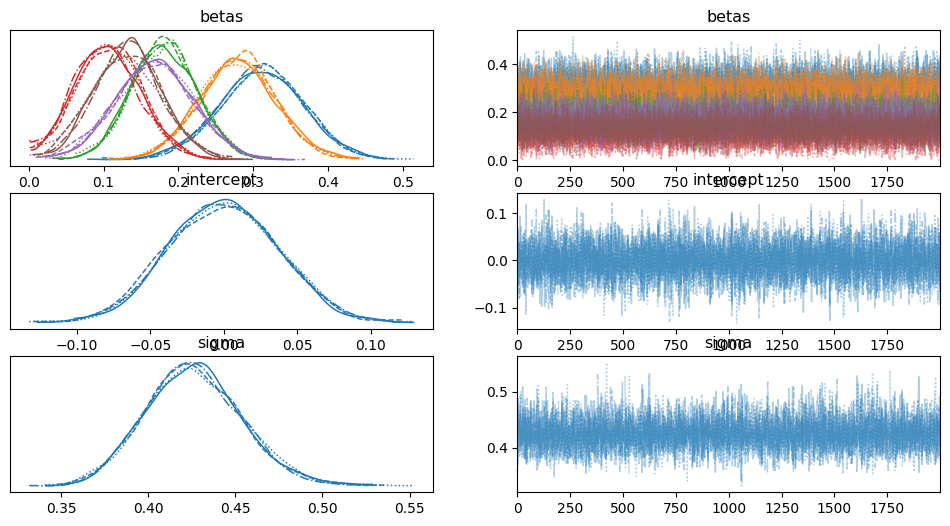

In [23]:
# Visual Check
az.plot_trace(trace)

In [24]:
## Channel Contribution Estimation

beta_means = trace.posterior['betas'].mean(dim=("chain","draw")).values

contribution = X * beta_means

channel_contribution = pd.DataFrame(
contribution,
columns=channels,
index=df.index
)

In [25]:
beta_means

array([0.31127306, 0.2784997 , 0.18104109, 0.10587047, 0.16759406,
       0.13126242])

In [ ]:
# Model Evaluation

from sklearn.metrics import r2_score

pred = X.dot(beta_means)

r2 = r2_score(y, pred)

print("R2:", r2)




In [ ]:
wmape = np.sum(np.abs(y - pred)) / np.sum(y)

print("WMAPE:", wmape)